# 8.20 — Cross-temporal × cross-variable decoding (binary variables)

Reuses the **binary decoders saved by 8.11** (`difficulty_level` / `choice` / `hmm_state`, all
`{0,1}`). For every ordered pair (train variable A, test variable B) and every (train bin, test bin)
across **all epochs**, apply A's trained decoder to B's held-out test pseudo-population → accuracy.

Result per prior direction = a **3×3 grid of heatmaps** (rows = train var, cols = test var): the
**diagonal** panels are each variable's cross-temporal decoding (Fig 5c/5e), the **off-diagonal**
panels are cross-variable generalization. Accuracy only (no significance — that's the shuffle-null
step in 8.10/8.11). Reuse is valid because trial counts are identical across epochs, so a repeat's
train/test split is the same across epochs.


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import pickle
import numpy as np
import torch
import torch.nn as nn

from imports import *  # Path, np, pd, plt
from config import dir_config, ephys_config
from src.utils import decoding_utils

processed_dir = Path(dir_config.data.processed)
alignments    = list(ephys_config["alignment_settings_GP"].keys())
binary_vars   = ["difficulty_level", "choice", "hmm_state"]
var_title     = {"difficulty_level": "difficulty", "choice": "choice", "hmm_state": "hmm_state"}

session_to_exclude = ["210210_GP_JP", "241209_GP_TZ"]
session_metadata = pd.read_csv(processed_dir / "sessions_metadata.csv")
session_metadata = session_metadata[~session_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)
neuron_metadata = pd.read_csv(processed_dir / "neuron_metadata.csv")
neuron_metadata = neuron_metadata[~neuron_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)
with open(processed_dir / "glm_hmm_models" / "glm_hmm_masked_final.pkl", "rb") as f:
    glm_hmm = pickle.load(f)

trial_info = decoding_utils.prepare_trial_info(session_metadata, glm_hmm)
trial_info = trial_info[(trial_info.outcome == 1) & (trial_info.reaction_time >= 250)].reset_index(drop=True)
trial_info["abs_coherence"] = trial_info.signed_coherence.abs()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/HONGYE/opt/anaconda3/envs/prior-sc/lib/python3.11/site-packages/traitlets/con

In [3]:
# --- decoder model (must match 8.10/8.11 arch for state_dict reload) ---
class LinearDecoder(nn.Module):
    def __init__(self, n_input, n_classes, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(nn.BatchNorm1d(n_input), nn.Dropout(dropout), nn.Linear(n_input, n_classes))
    def forward(self, x):
        return self.net(x)

In [4]:
# --- load 8.11 binary models + ephys ---
with open(processed_dir / "decoder" / "decoding_models_8.11.pkl", "rb") as f:
    bundle = pickle.load(f)
models_all = bundle["models"]
N_TEST    = bundle["hyperparams"]["n_test"]
N_REPEATS = bundle["hyperparams"]["n_repeats"]
print("decoder arch:", bundle["decoder_arch"], "| N_TEST", N_TEST, "| N_REPEATS", N_REPEATS)

try:
    ephys_data  # noqa: F821
    print("ephys_data already loaded.")
except NameError:
    with open(processed_dir / "ephys_neuron_wise.pkl", "rb") as f:
        ephys_data = pickle.load(f)
    print("loaded ephys_neuron_wise.pkl")

decoder arch: BatchNorm1d(n_input) -> Dropout(0.5) -> Linear(n_input, n_classes) | N_TEST 200 | N_REPEATS 8
loaded ephys_neuron_wise.pkl


In [5]:
# --- cross-evaluate: for each direction, all (train var A, test var B) x (train bin, test bin) ---
cross = {}          # cross[direction][(A,B)] = (G, G) accuracy matrix
global_bins = {}    # global_bins[direction] = [(alignment, local_bin, t0, t1, centre_ms), ...]

for direction in ["toRF", "awayRF"]:
    di = trial_info[trial_info.prior_direction == direction].reset_index(drop=True)
    sessions = sorted(di.session_id.unique())
    session_data, neuron_positions, n_total, label_values = decoding_utils.get_session_trial_data(
        sessions, di, neuron_metadata, ephys_data, alignments)
    dmodels = models_all[direction]["decode"]
    assert n_total == models_all[direction]["n_input"], "neuron count mismatch vs saved models"

    # global bins = concat each epoch's saved bin_edges (same across variables)
    gb = []
    for al in alignments:
        for bi, (t0, t1) in enumerate(dmodels["difficulty_level"][al]["bin_edges"]):
            gb.append((al, bi, t0, t1, int(dmodels["difficulty_level"][al]["centres"][bi])))
    global_bins[direction] = gb
    G = len(gb)
    print(f"\n[{direction}] {n_total} neurons, {G} global bins")

    def build_test(var, gj, r):
        """Rebuild var's held-out test pseudo-population at global bin gj for repeat r -> (tensor, y)."""
        al, _, t0, t1, _ = gb[gj]
        info = dmodels[var][al]["fitted"]; vals = dmodels[var][al]["label_values"]
        test_idx = info["splits"][r]["test_idx"]
        X = np.zeros((len(vals) * N_TEST, n_total))
        for vi, vv in enumerate(vals):
            s0 = vi * N_TEST
            for sid in info["eligible_sessions"]:
                mask = session_data[al][sid][var] == vv
                rate = session_data[al][sid]["spikes"][mask][:, :, t0:t1].mean(-1)
                X[s0:s0 + N_TEST, neuron_positions[sid]] = rate[test_idx[(vi, sid)]]
        return (torch.tensor(X, dtype=torch.float32),
                torch.tensor(np.repeat(np.arange(len(vals)), N_TEST), dtype=torch.long))

    def load_model(var, gi, r):
        al, bi, *_ = gb[gi]
        ncl = len(dmodels[var][al]["label_values"])
        m = LinearDecoder(n_total, ncl); m.load_state_dict(dmodels[var][al]["fitted"]["models"][(r, bi)]); m.eval()
        return m

    cross[direction] = {(A, B): np.zeros((G, G)) for A in binary_vars for B in binary_vars}
    for r in range(N_REPEATS):
        test_cache = {(B, gj): build_test(B, gj, r) for B in binary_vars for gj in range(G)}
        for A in binary_vars:
            for gi in range(G):
                model = load_model(A, gi, r)
                with torch.no_grad():
                    for B in binary_vars:
                        for gj in range(G):
                            Xb, yb = test_cache[(B, gj)]
                            pred = model(Xb).argmax(1)
                            cross[direction][(A, B)][gi, gj] += (pred == yb).float().mean().item()
        print(f"  repeat {r + 1}/{N_REPEATS}", end="\r")
    for k in cross[direction]:
        cross[direction][k] /= N_REPEATS
    print()

with open(processed_dir / "decoder" / "decoding_cross_8.20.pkl", "wb") as f:
    pickle.dump({"cross": cross, "global_bins": global_bins, "binary_vars": binary_vars}, f)
print("saved decoder/decoding_cross_8.20.pkl")


[toRF] 74 neurons, 21 global bins
  repeat 8/8

[awayRF] 68 neurons, 21 global bins
  repeat 8/8
saved decoder/decoding_cross_8.20.pkl


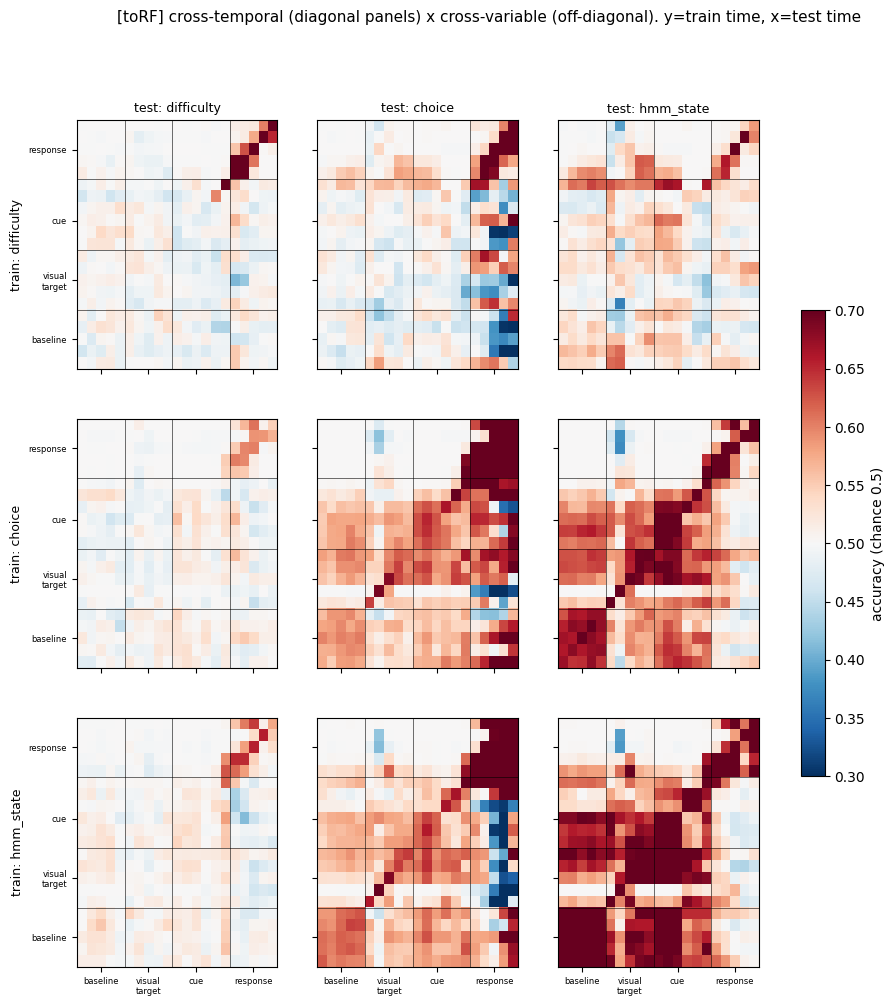

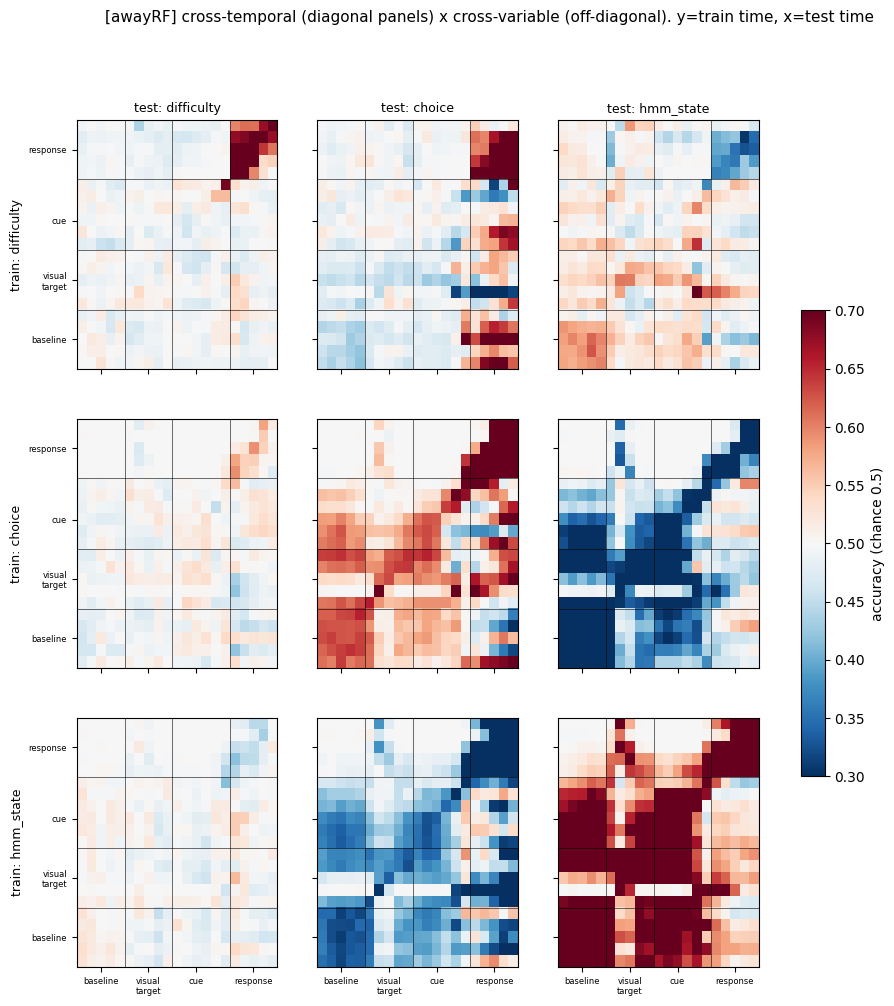

In [6]:
# --- plot: 3x3 grid of heatmaps per direction (rows=train var, cols=test var) ---
for direction in cross:
    gb = global_bins[direction]; G = len(gb)
    epoch_seq = [g[0] for g in gb]
    bounds = [i for i in range(1, G) if epoch_seq[i] != epoch_seq[i - 1]]         # epoch transitions
    # tick at each epoch centre
    tick_pos, tick_lab = [], []
    for al in alignments:
        idx = [i for i, e in enumerate(epoch_seq) if e == al]
        if idx:
            tick_pos.append(int(np.mean(idx))); tick_lab.append(al if al != "visual" else "visual\ntarget")

    fig, axes = plt.subplots(len(binary_vars), len(binary_vars), figsize=(11, 11), sharex=True, sharey=True)
    for i, A in enumerate(binary_vars):
        for j, B in enumerate(binary_vars):
            ax = axes[i, j]
            im = ax.imshow(cross[direction][(A, B)], origin="lower", cmap="RdBu_r",
                           vmin=0.3, vmax=0.7, aspect="auto")
            for b in bounds:
                ax.axhline(b - 0.5, c="k", lw=0.4); ax.axvline(b - 0.5, c="k", lw=0.4)
            ax.set_xticks(tick_pos); ax.set_yticks(tick_pos)
            ax.set_xticklabels(tick_lab, fontsize=6); ax.set_yticklabels(tick_lab, fontsize=6)
            if i == 0: ax.set_title(f"test: {var_title[B]}", fontsize=9)
            if j == 0: ax.set_ylabel(f"train: {var_title[A]}", fontsize=9)
    fig.colorbar(im, ax=axes, shrink=0.55, label="accuracy (chance 0.5)")
    fig.suptitle(f"[{direction}] cross-temporal (diagonal panels) x cross-variable (off-diagonal). "
                 f"y=train time, x=test time", fontsize=11)
    plt.show()